In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


df = pd.read_csv('dvi_dim.csv')


In [2]:
X = df

In [ ]:
X = df.drop(columns=['label']).values

Empirinis metodas

In [3]:
m = X.shape[0]
klasteriai = int(np.sqrt(m / 2))
print(f"Geriausias klasteriu skaicius: {klasteriai}")

Geriausias klasteriu skaicius: 27


Elbow metodas

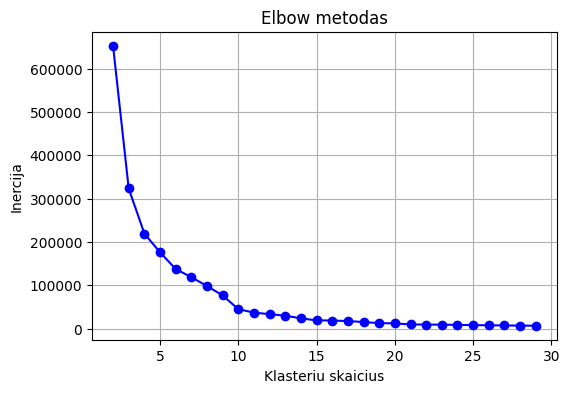

In [4]:
inercija = []
K = range(2, 30)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inercija.append(kmeans.inertia_) # metrika, rodanti kaip arti yra taskai prie savo klasterio centro

plt.figure(figsize=(6, 4))
plt.plot(K, inercija, 'bo-')
plt.xlabel('Klasteriu skaicius')
plt.ylabel('Inercija')
plt.title('Elbow metodas')
plt.grid(True)
plt.show()


Vidutinio silueto metodas

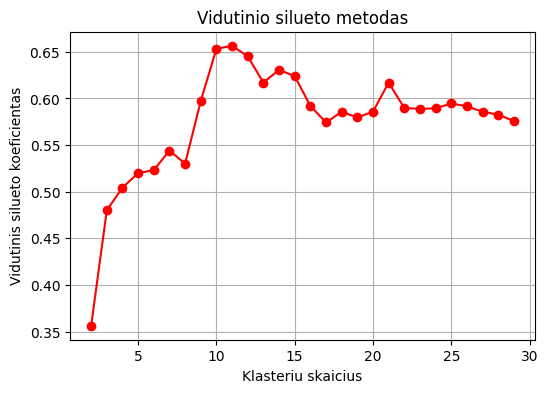

Geriausias klasteriu skaicius: 11


In [5]:
siluetas = []
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    siluetas.append(score)

plt.figure(figsize=(6, 4))
plt.plot(K, siluetas, 'ro-')
plt.xlabel('Klasteriu skaicius')
plt.ylabel('Vidutinis silueto koeficientas')
plt.title('Vidutinio silueto metodas')
plt.grid(True)
plt.show()

klasteriai = K[np.argmax(siluetas)]
print(f"Geriausias klasteriu skaicius: {klasteriai}")